# Heerlen-Aachen Annotated Steel Microstructure Dataset
## Three-Way Model Comparison: Classical CV vs U-Net vs SegNet

This notebook is a **standalone continuation** of Section 9 from
`nature_scidata_heerlen_aachen_steel_segnet_contour_detection.ipynb`.
It loads pre-saved evaluation pickle files produced by the three
preceding notebooks and performs a comprehensive comparison.

| # | Method | Source notebook |
|---|---|---|
| 1 | **Classical CV** | `nature_scidata_heerlen_aachen_steel_auto_contour_detection.ipynb` |
| 2 | **U-Net** | `nature_scidata_heerlen_aachen_steel_unet_contour_detection.ipynb` |
| 3 | **SegNet** | `nature_scidata_heerlen_aachen_steel_segnet_contour_detection.ipynb` |

**Prerequisites — run these notebooks first and save their evaluation pickles:**
- `nature_scidata_dfEvaluation.pickle` (Classical CV)
- `nature_scidata_dfUNetEvaluation.pickle` (U-Net)
- `nature_scidata_dfSegNetEvaluation.pickle` (SegNet)
- `nature_scidata_dfPOIPolygonContourShapely.pickle` (Classical CV contours, for visual overlay)
- `nature_scidata_dfPOIPolygonUNetContourShapely.pickle` (U-Net contours, for visual overlay)
- `nature_scidata_dfPOIPolygonSegNetContourShapely.pickle` (SegNet contours, for visual overlay)

Contact: Based on dataset by Deniz Iren, PhD (deniz.iren@ou.nl)

---
## 0. File Paths

Set all paths in this single cell before running anything else.

In [2]:
# ── Image directory ───────────────────────────────────────────────────────────
path_folder_images_png = 'PNG/'

# ── Evaluation pickle files (IOU scores per island, one per model) ────────────
# Written by the auto_contour_detection notebook (Classical CV baseline)
path_file_ClassicalEvaluations = 'nature_scidata_dfEvaluation.pickle'

# Written by the unet_contour_detection notebook
path_file_UNetEvaluations      = 'nature_scidata_dfUNetEvaluation.pickle'

# Written by the segnet_contour_detection notebook
path_file_SegNetEvaluations    = 'nature_scidata_dfSegNetEvaluation.pickle'

# ── Contour pickle files (full Shapely polygon contours, for visual overlay) ──
# Written by the auto_contour_detection notebook
path_file_ClassicalContours    = 'nature_scidata_dfPOIPolygonContourShapely.pickle'

# Written by the unet_contour_detection notebook
path_file_UNetContours         = 'nature_scidata_dfPOIPolygonUNetContourShapely.pickle'

# Written by the segnet_contour_detection notebook
path_file_SegNetContours       = 'nature_scidata_dfPOIPolygonSegNetContourShapely.pickle'

# ── Model weight files (needed only for Section 11 speed benchmark) ───────────
path_unet_weights              = 'unet_ma_island_weights.pth'
path_segnet_weights            = 'segnet_ma_island_weights.pth'

# ── Misc settings ─────────────────────────────────────────────────────────────
PATCH_SIZE = 256    # must match what both models were trained with
DEVICE     = 'cuda' # change to 'cpu' if no GPU available

---
## 1. Imports

In [3]:
import pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPolygon
from scipy.stats import gaussian_kde

import cv2
from shapely.geometry import Polygon

import torch
import torch.nn as nn
import torchvision.transforms.functional as TF

print('Imports OK')
DEVICE = torch.device(DEVICE if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)

Imports OK
Device: cpu


---
## 2. Load Evaluation Results

Load the three evaluation dataframes saved by the preceding notebooks.
Each has columns: `image_url`, `point`, `polygon`, `point_shapely`,
`poly_shapely`, `contour_polygon_shapely`, `area_poly`, `area_contour`, `IOU`.

In [6]:
# ── Load evaluation dataframes ────────────────────────────────────────────────
with open(path_file_ClassicalEvaluations, 'rb') as fh:
    dfClassical = pickle.load(fh)

with open(path_file_UNetEvaluations, 'rb') as fh:
    dfUNet = pickle.load(fh)

with open(path_file_SegNetEvaluations, 'rb') as fh:
    dfSegNet = pickle.load(fh)

# ── Load contour dataframes (needed for visual overlay in Section 9) ──────────
with open(path_file_ClassicalContours, 'rb') as fh:
    dfClassicalContours = pickle.load(fh)

with open(path_file_UNetContours, 'rb') as fh:
    dfUNetContours = pickle.load(fh)

with open(path_file_SegNetContours, 'rb') as fh:
    dfSegNetContours = pickle.load(fh)

# ── Quick sanity check ────────────────────────────────────────────────────────
for name, df in [('Classical CV', dfClassical), ('U-Net', dfUNet), ('SegNet', dfSegNet)]:
    print(f'{name:15s}: {len(df):5d} islands | '
          f'mean IOU = {df["IOU"].mean():.4f} | '
          f'detected = {(df["IOU"] > 0).sum():5d} '
          f'({(df["IOU"] > 0).sum()/len(df)*100:.1f}%)')

C:\Users\Admin\AppData\Local\Temp\ipykernel_19116\3671440610.py:13: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dfClassicalContours = pickle.load(fh)
C:\Users\Admin\AppData\Local\Temp\ipykernel_19116\3671440610.py:13: UserWarning: Unpickling a shapely <2.0 geometry object. Please save the pickle again as this compatibility may be removed in a future version of shapely.
  dfClassicalContours = pickle.load(fh)


Classical CV   :  8909 islands | mean IOU = 0.3578 | detected =  6865 (77.1%)
U-Net          :  8909 islands | mean IOU = 0.4025 | detected =  6269 (70.4%)
SegNet         :  8909 islands | mean IOU = 0.4298 | detected =  6706 (75.3%)


---
## 3. Summary Statistics Table

A single table collecting the most important metrics for all three models.

In [7]:
def summarise(df, name):
    """Compute key IOU metrics for one model's evaluation dataframe."""
    iou      = df['IOU']
    detected = (iou > 0).sum()
    return {
        'Model'          : name,
        'Mean IOU'       : round(iou.mean(),   4),
        'Median IOU'     : round(iou.median(), 4),
        'Std IOU'        : round(iou.std(),    4),
        'IOU > 0.5 (%)'  : round((iou > 0.50).sum() / len(iou) * 100, 1),
        'IOU > 0.75 (%)' : round((iou > 0.75).sum() / len(iou) * 100, 1),
        'Detected (%)'   : round(detected / len(iou) * 100, 1),
        'n'              : len(iou),
    }

summary = pd.DataFrame([
    summarise(dfClassical, 'Classical CV'),
    summarise(dfUNet,      'U-Net'),
    summarise(dfSegNet,    'SegNet'),
]).set_index('Model')

print('\n=== Three-Way Model Comparison ===')
print(summary.to_string())
summary


=== Three-Way Model Comparison ===
              Mean IOU  Median IOU  Std IOU  IOU > 0.5 (%)  IOU > 0.75 (%)  Detected (%)     n
Model                                                                                         
Classical CV    0.3578      0.3863   0.2615           36.3             4.8          77.1  8909
U-Net           0.4025      0.4478   0.3179           45.3            17.8          70.4  8909
SegNet          0.4298      0.4813   0.3139           48.3            20.6          75.3  8909


,Mean IOU,Median IOU,Std IOU,IOU > 0.5 (%),IOU > 0.75 (%),Detected (%),n
Model,,,,,,,
Classical CV,0.3578,0.3863,0.2615,36.3,4.8,77.1,8909
U-Net,0.4025,0.4478,0.3179,45.3,17.8,70.4,8909
SegNet,0.4298,0.4813,0.3139,48.3,20.6,75.3,8909


---
## 4. IOU Distribution Histograms

One histogram per model with mean (solid) and median (dashed) lines marked.

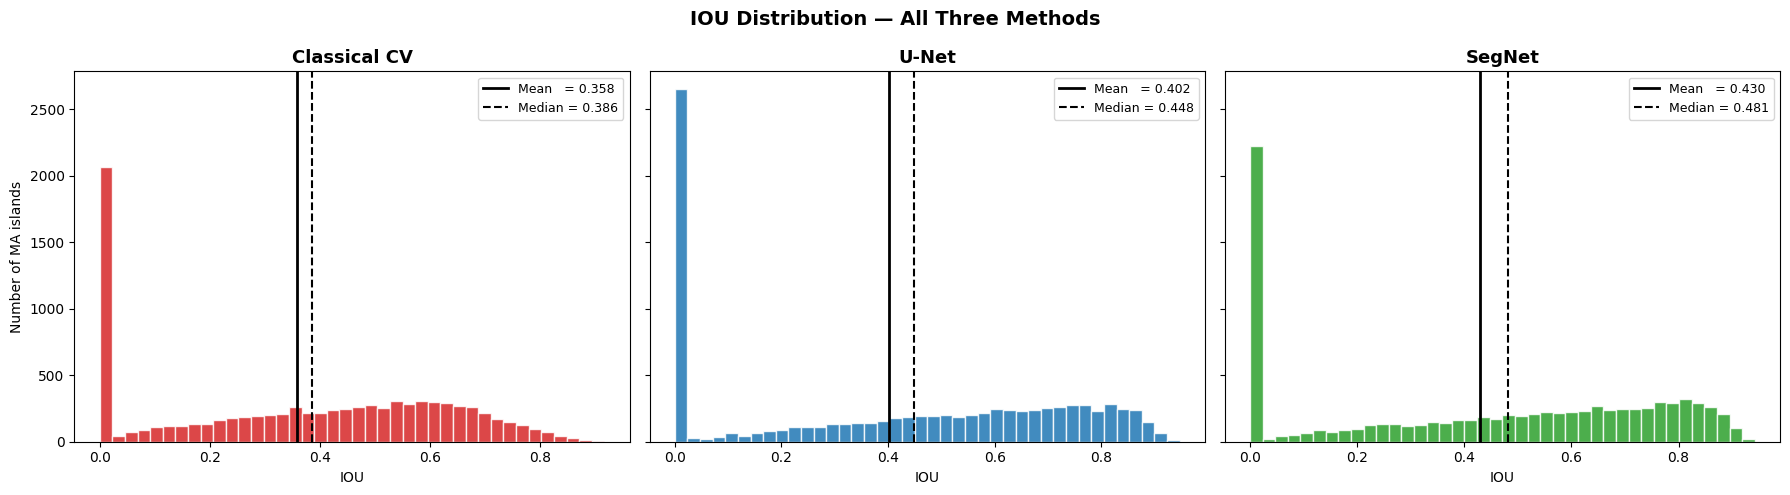

In [8]:
models = [
    (dfClassical, 'Classical CV', '#d62728'),
    (dfUNet,      'U-Net',        '#1f77b4'),
    (dfSegNet,    'SegNet',       '#2ca02c'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, (df, name, color) in zip(axes, models):
    iou = df['IOU']
    ax.hist(iou, bins=40, color=color, alpha=0.85, edgecolor='white')
    ax.axvline(iou.mean(),   color='black', linestyle='-',  linewidth=2,
               label=f'Mean   = {iou.mean():.3f}')
    ax.axvline(iou.median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median = {iou.median():.3f}')
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.set_xlabel('IOU')
    ax.legend(fontsize=9)

axes[0].set_ylabel('Number of MA islands')
plt.suptitle('IOU Distribution — All Three Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Overlapping KDE Density Plot

All three models on a single axis using Gaussian kernel density estimation.
Dotted vertical lines mark each model's mean IOU.

---
## 5. Overlapping KDE Density Plot

All three models on a single axis using Gaussian kernel density estimation.
Dotted vertical lines mark each model's mean IOU.

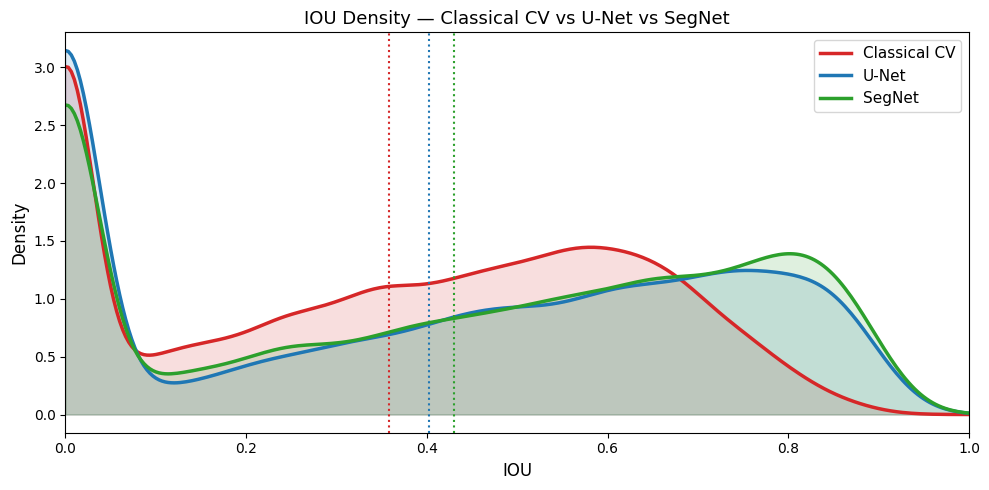

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
x_vals  = np.linspace(0, 1, 300)

for df, name, color in models:
    iou = df['IOU'].values
    kde = gaussian_kde(iou, bw_method=0.12)
    ax.plot(x_vals, kde(x_vals), color=color, linewidth=2.5, label=name)
    ax.fill_between(x_vals, kde(x_vals), alpha=0.15, color=color)
    ax.axvline(iou.mean(), color=color, linestyle=':', linewidth=1.5)

ax.set_xlabel('IOU', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('IOU Density — Classical CV vs U-Net vs SegNet', fontsize=13)
ax.legend(fontsize=11)
ax.set_xlim(0, 1)
plt.tight_layout()
plt.show()

---
## 6. Bar Chart — Key Metrics Side-by-Side

Five metrics plotted as grouped bars for quick visual comparison.

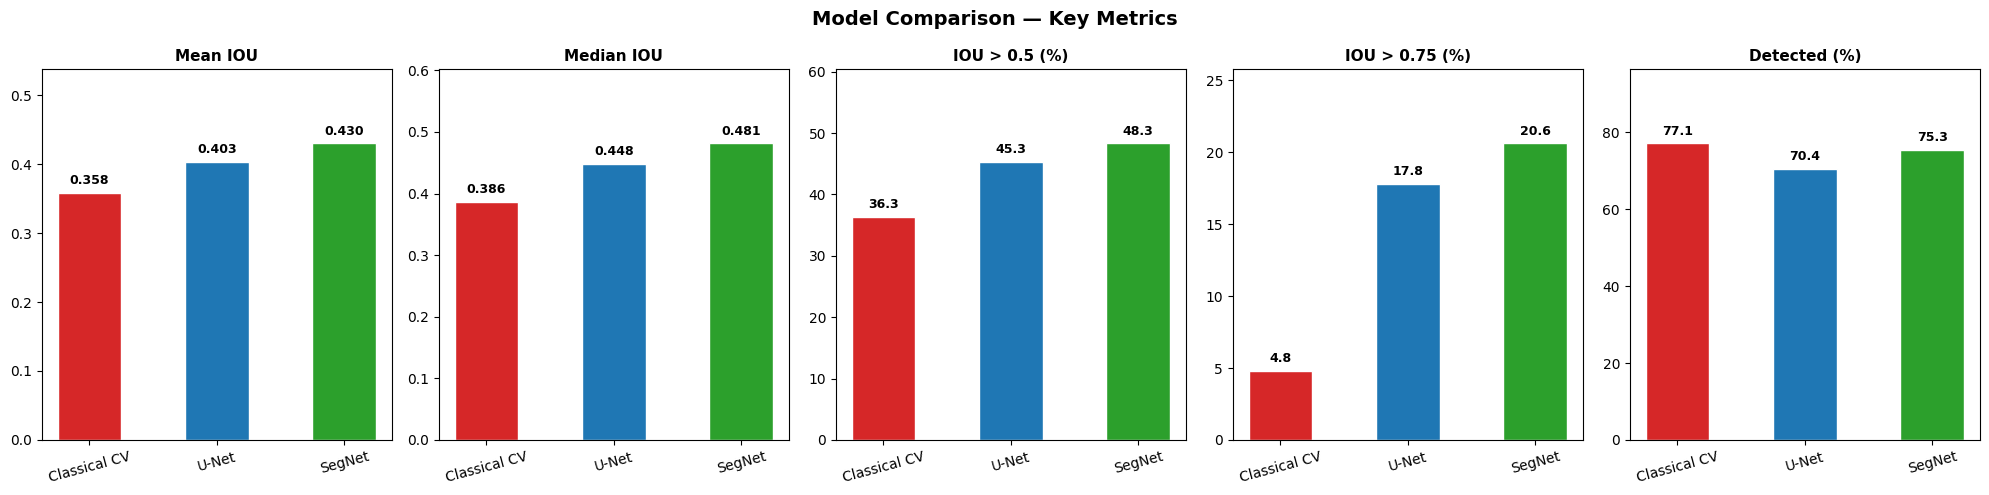

In [10]:
metrics      = ['Mean IOU', 'Median IOU', 'IOU > 0.5 (%)', 'IOU > 0.75 (%)', 'Detected (%)']
model_names  = summary.index.tolist()
model_colors = ['#d62728', '#1f77b4', '#2ca02c']

fig, axes = plt.subplots(1, len(metrics), figsize=(20, 5))

for ax, metric in zip(axes, metrics):
    vals = summary[metric].values
    bars = ax.bar(model_names, vals, color=model_colors, edgecolor='white', width=0.5)
    ax.set_title(metric, fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.25)
    for bar, val in zip(bars, vals):
        fmt = f'{val:.3f}' if metric in ('Mean IOU', 'Median IOU', 'Std IOU') else f'{val:.1f}'
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.02,
                fmt, ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison — Key Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. IOU Category Breakdown — Stacked Bar

Each MA island is assigned to one of five quality bands.
The stacked bar shows what proportion of all islands each model
places into each band.

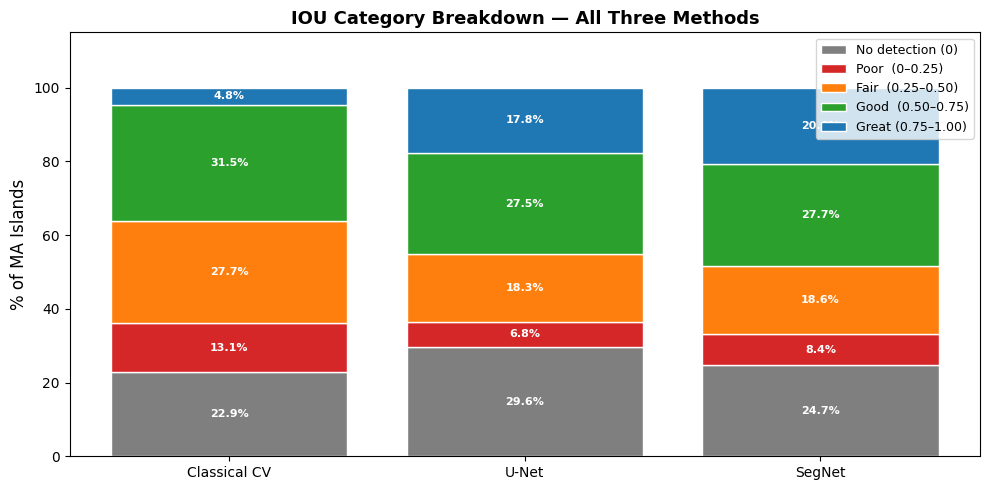

In [11]:
def iou_category_pcts(df):
    """Return a dict of IOU quality band → percentage of all islands."""
    iou = df['IOU']
    n   = len(iou)
    return {
        'No detection (0)'   : (iou == 0).sum()                      / n * 100,
        'Poor  (0–0.25)'     : ((iou >  0)    & (iou <= 0.25)).sum() / n * 100,
        'Fair  (0.25–0.50)'  : ((iou >  0.25) & (iou <= 0.50)).sum() / n * 100,
        'Good  (0.50–0.75)'  : ((iou >  0.50) & (iou <= 0.75)).sum() / n * 100,
        'Great (0.75–1.00)'  : (iou >  0.75).sum()                   / n * 100,
    }

cat_colors = ['#7f7f7f', '#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']
cat_data   = {
    'Classical CV' : iou_category_pcts(dfClassical),
    'U-Net'        : iou_category_pcts(dfUNet),
    'SegNet'       : iou_category_pcts(dfSegNet),
}
cat_df = pd.DataFrame(cat_data).T

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(3)

for col, color in zip(cat_df.columns, cat_colors):
    vals = cat_df[col].values
    bars = ax.bar(cat_df.index, vals, bottom=bottom,
                  color=color, label=col, edgecolor='white')
    for bar, val in zip(bars, vals):
        if val > 3:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_y()  + bar.get_height() / 2,
                    f'{val:.1f}%', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_ylabel('% of MA Islands', fontsize=12)
ax.set_title('IOU Category Breakdown — All Three Methods',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_ylim(0, 115)
plt.tight_layout()
plt.show()

---
## 8. Per-Island Scatter — Pairwise IOU Comparison

Each dot is one MA island. Points **above** the diagonal mean the
y-axis model outperformed the x-axis model on that specific island.
This reveals whether models have complementary strengths.

Islands matched across all three models: 8909


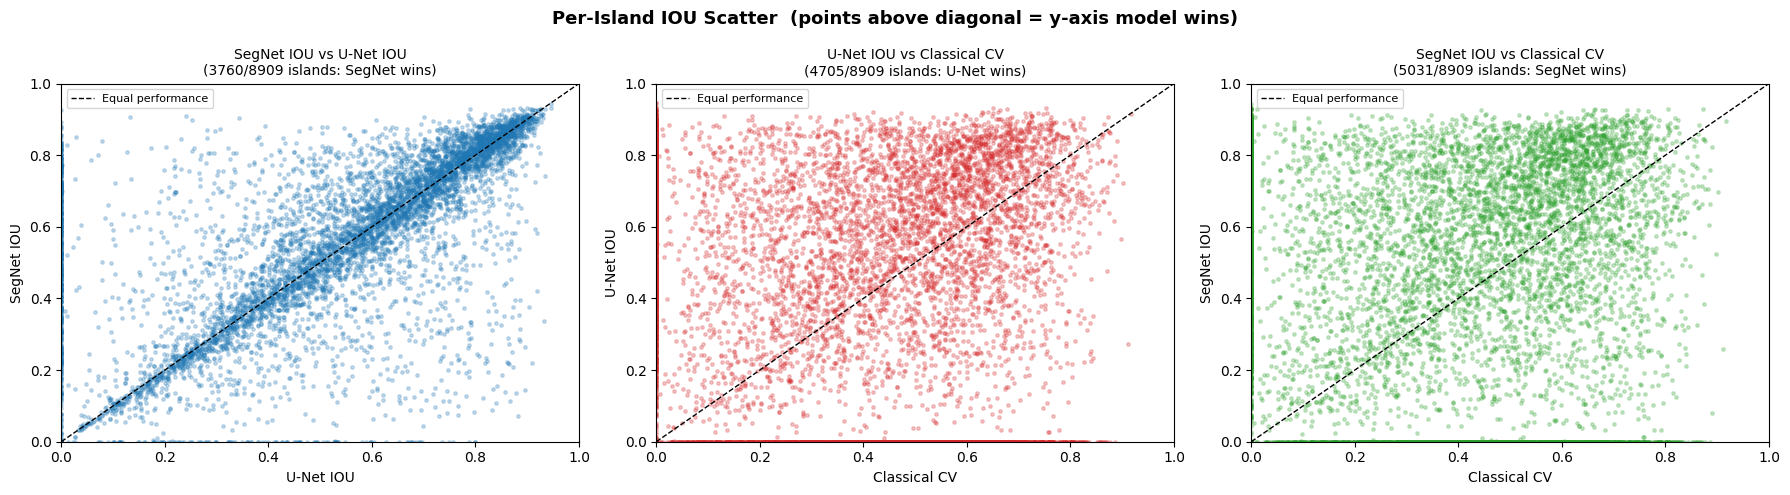

In [12]:
# ── Align all three evaluation dataframes on the same islands ─────────────────
# Key = image filename + point coordinate string
dfClassical['key'] = dfClassical['image_url'] + '_' + dfClassical['point'].astype(str)
dfUNet['key']      = dfUNet['image_url']      + '_' + dfUNet['point'].astype(str)
dfSegNet['key']    = dfSegNet['image_url']    + '_' + dfSegNet['point'].astype(str)

merged = (
    dfUNet[['key', 'IOU']].rename(columns={'IOU': 'IOU_UNet'})
    .merge(dfSegNet[['key', 'IOU']].rename(columns={'IOU': 'IOU_SegNet'}),    on='key')
    .merge(dfClassical[['key', 'IOU']].rename(columns={'IOU': 'IOU_Classical'}), on='key')
)
print(f'Islands matched across all three models: {len(merged)}')

# ── Three pairwise scatter plots ──────────────────────────────────────────────
pairs = [
    ('IOU_UNet',      'IOU_SegNet',    'U-Net IOU',    'SegNet IOU',   '#1f77b4'),
    ('IOU_Classical', 'IOU_UNet',      'Classical CV', 'U-Net IOU',    '#d62728'),
    ('IOU_Classical', 'IOU_SegNet',    'Classical CV', 'SegNet IOU',   '#2ca02c'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (xcol, ycol, xlabel, ylabel, color) in zip(axes, pairs):
    ax.scatter(merged[xcol], merged[ycol], alpha=0.25, s=6, color=color)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Equal performance')
    n_better = (merged[ycol] > merged[xcol]).sum()
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.set_title(
        f'{ylabel} vs {xlabel}\n'
        f'({n_better}/{len(merged)} islands: {ylabel.split()[0]} wins)',
        fontsize=10
    )
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.suptitle(
    'Per-Island IOU Scatter  (points above diagonal = y-axis model wins)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

---
## 9. Box Plot — IOU Distribution per Model

Box-and-whisker view of the IOU distribution.
Diamond markers (◆) show each model's mean IOU.

C:\Users\Admin\AppData\Local\Temp\ipykernel_19116\4188510638.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


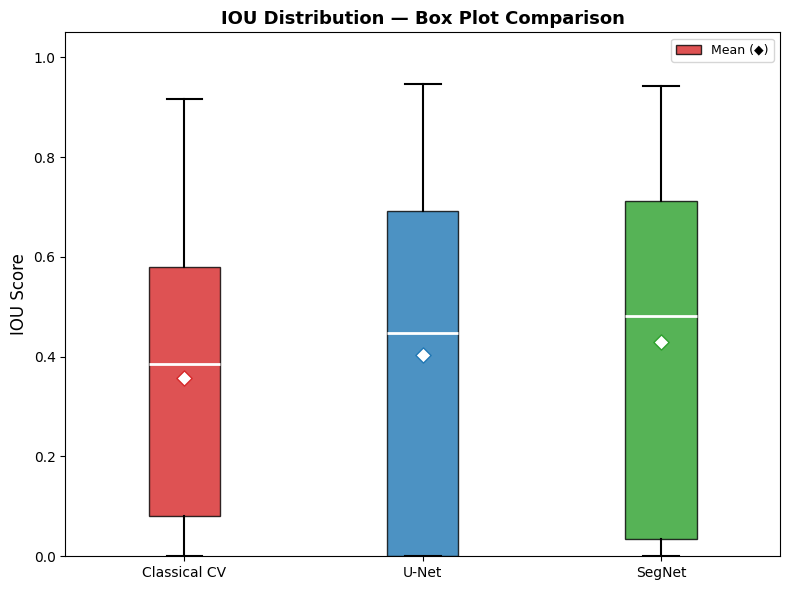

In [13]:
iou_data   = [dfClassical['IOU'].values, dfUNet['IOU'].values, dfSegNet['IOU'].values]
iou_labels = ['Classical CV', 'U-Net', 'SegNet']
iou_colors = ['#d62728', '#1f77b4', '#2ca02c']

fig, ax = plt.subplots(figsize=(8, 6))
bp = ax.boxplot(
    iou_data, labels=iou_labels, patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    whiskerprops=dict(linewidth=1.5),
    capprops=dict(linewidth=1.5),
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
for patch, color in zip(bp['boxes'], iou_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

for i, vals in enumerate(iou_data):
    ax.scatter(i + 1, np.mean(vals), marker='D', color='white',
               edgecolors=iou_colors[i], s=60, zorder=5,
               label='Mean' if i == 0 else '')

ax.set_ylabel('IOU Score', fontsize=12)
ax.set_title('IOU Distribution — Box Plot Comparison', fontsize=13, fontweight='bold')
ax.legend(['Mean (◆)'], fontsize=9)
ax.set_ylim(0, 1.05)
ax.axhline(0, color='grey', linewidth=0.5, linestyle=':')
plt.tight_layout()
plt.show()

---
## 10. Visual Side-by-Side: Same Island, Three Methods

For each sampled MA island, four columns are shown:

| Column | Content |
|---|---|
| SEM Image | Raw crop with expert polygon (red) |
| Classical CV | Orange contour + expert polygon (red dashed) |
| U-Net | Blue contour + expert polygon (red dashed) |
| SegNet | Green contour + expert polygon (red dashed) |

IOU scores are printed in each cell title.

In [14]:
# ── Align contour dataframes on the same key ──────────────────────────────────
dfClassicalContours['key'] = (dfClassicalContours['image_url'] + '_' +
                               dfClassicalContours['point'].astype(str))
dfUNetContours['key']      = (dfUNetContours['image_url']      + '_' +
                               dfUNetContours['point'].astype(str))
dfSegNetContours['key']    = (dfSegNetContours['image_url']    + '_' +
                               dfSegNetContours['point'].astype(str))

# Also propagate the key to the evaluation dfs (already done above)
# Build a merged key-IOU lookup so we can annotate each panel
iou_lookup = (
    dfClassical[['key', 'IOU']].rename(columns={'IOU': 'IOU_Classical'})
    .merge(dfUNet[['key', 'IOU']].rename(columns={'IOU': 'IOU_UNet'}),    on='key')
    .merge(dfSegNet[['key', 'IOU']].rename(columns={'IOU': 'IOU_SegNet'}), on='key')
)
print(f'Keys in IOU lookup: {len(iou_lookup)}')

Keys in IOU lookup: 8909


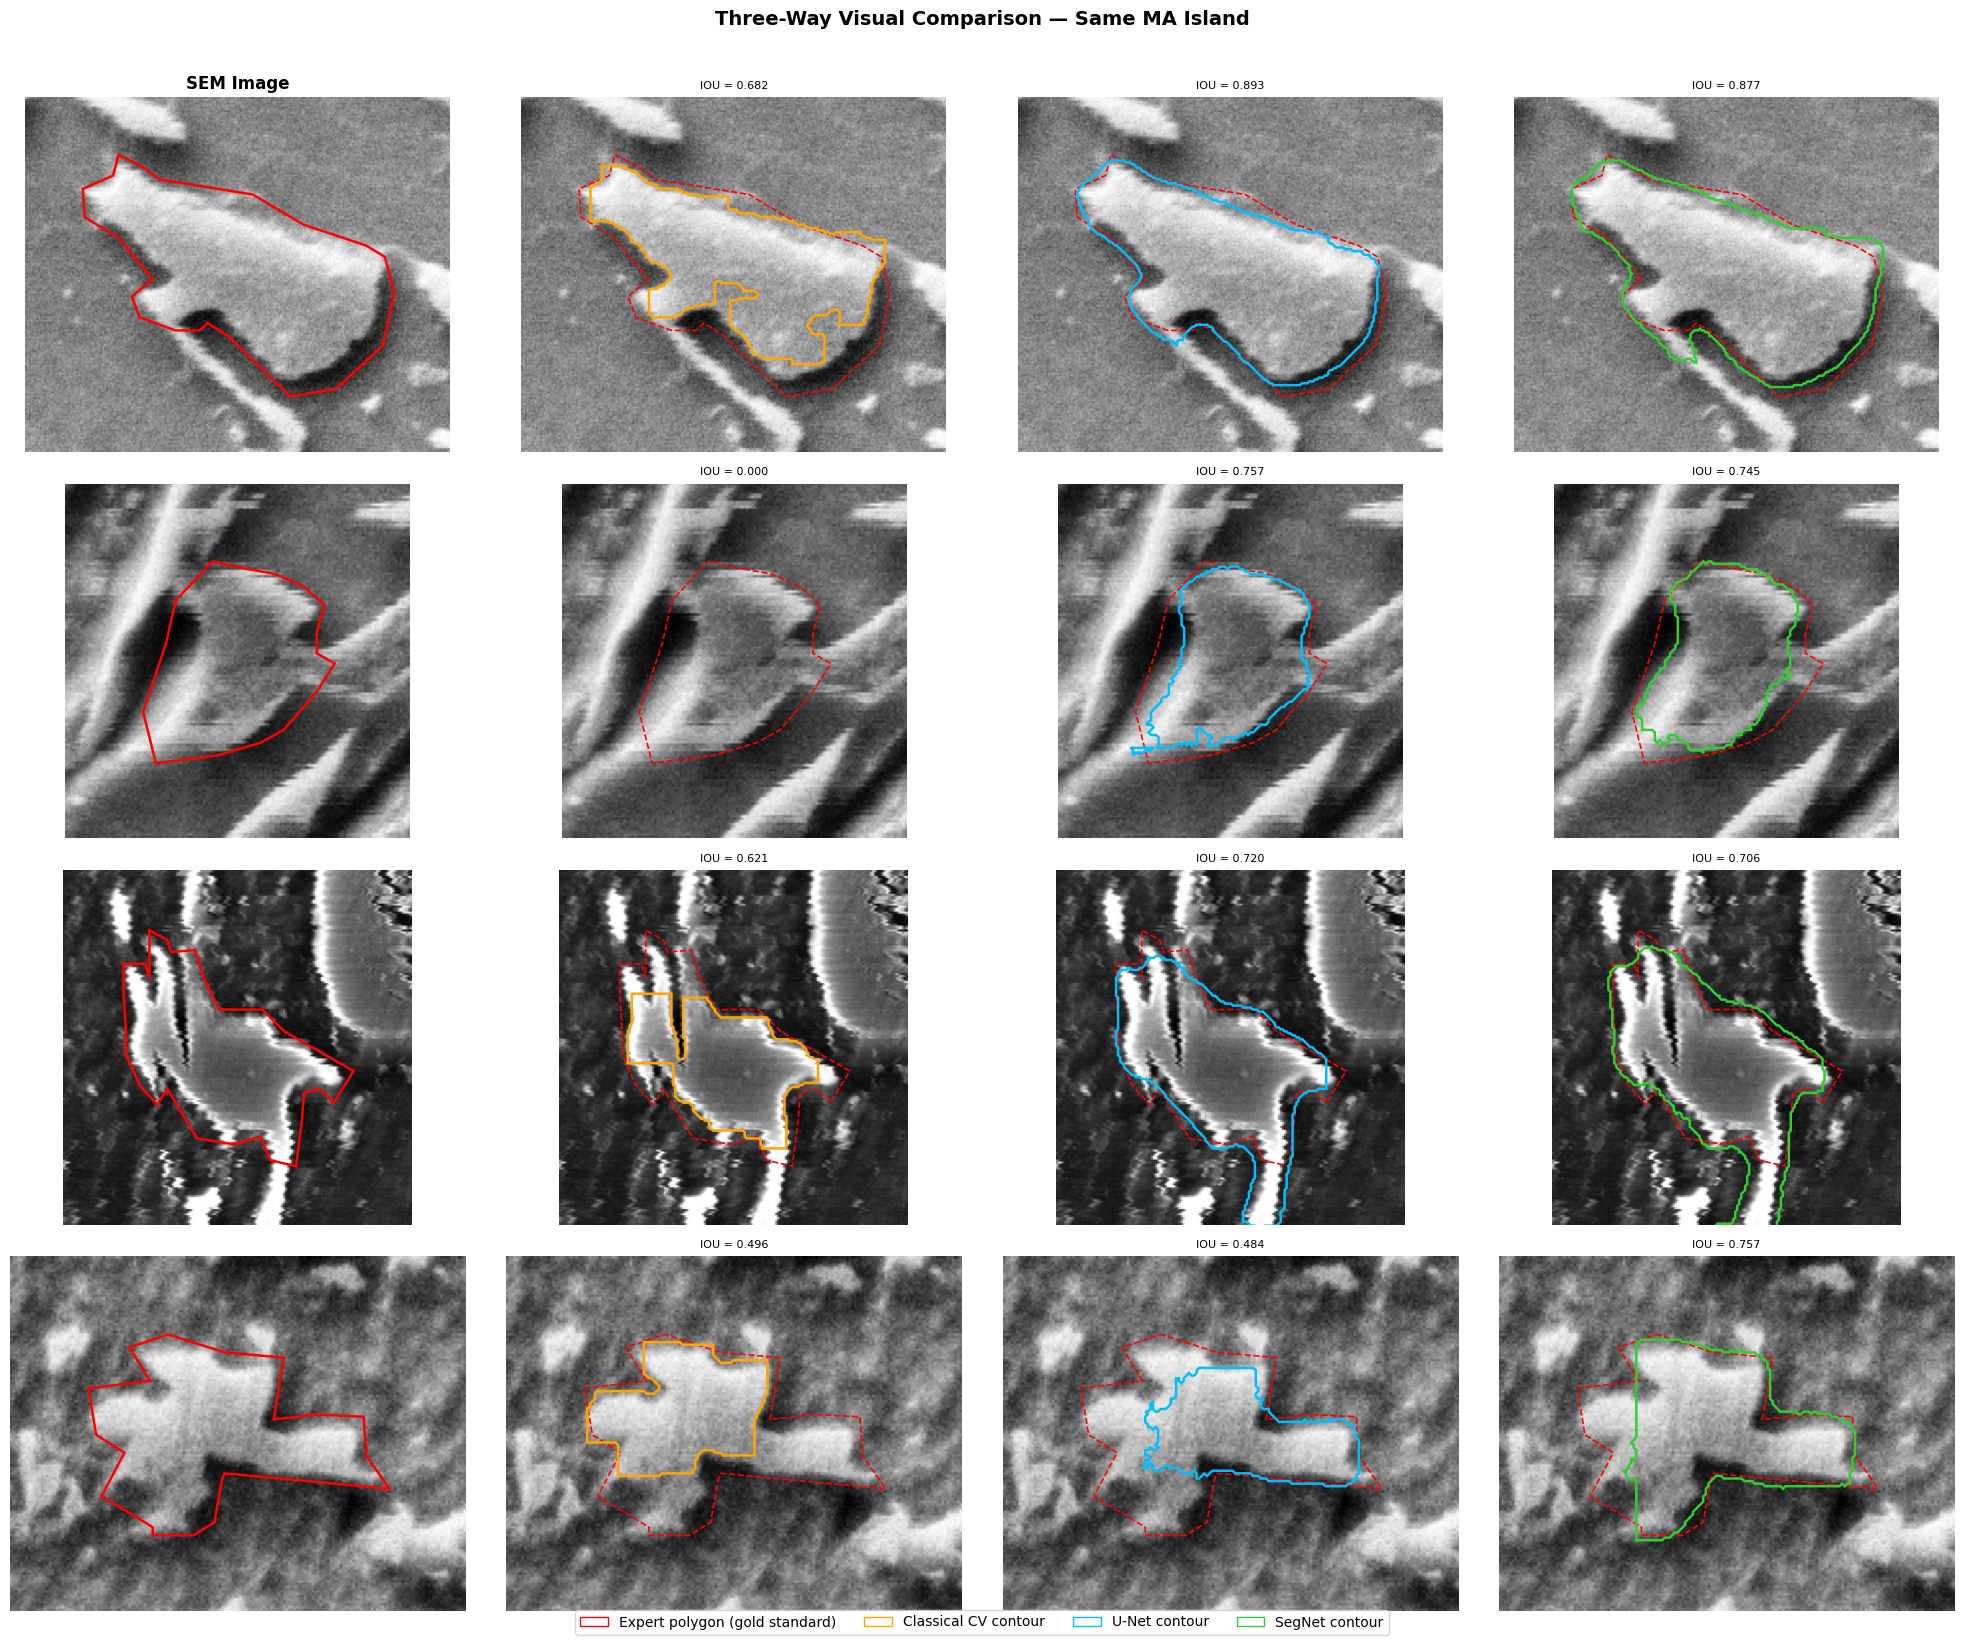

In [15]:
def visualize_three_way(iou_lookup, df_cl_cont, df_un_cont, df_sn_cont,
                        img_dir, n_samples=4, min_avg_iou=0.2, random_state=7):
    """
    For each sampled MA island show the SEM crop with three model contours
    overlaid next to the raw image.

    Parameters
    ----------
    iou_lookup    : merged dataframe with IOU_Classical, IOU_UNet, IOU_SegNet, key
    df_cl_cont    : Classical CV contours dataframe (has key + contour_polygon_shapely)
    df_un_cont    : U-Net contours dataframe
    df_sn_cont    : SegNet contours dataframe
    img_dir       : path to PNG image folder
    n_samples     : number of islands to display
    min_avg_iou   : minimum average IOU across DL models to include an island
    """
    # Filter to islands where at least the two DL models detected something
    eligible = iou_lookup[
        ((iou_lookup['IOU_UNet'] + iou_lookup['IOU_SegNet']) / 2) >= min_avg_iou
    ]
    samples = eligible.sample(min(n_samples, len(eligible)), random_state=random_state)

    fig, axes = plt.subplots(n_samples, 4, figsize=(20, n_samples * 4))
    if n_samples == 1:
        axes = axes[np.newaxis, :]

    col_titles = ['SEM Image', 'Classical CV', 'U-Net', 'SegNet']
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=12, fontweight='bold')

    for row_idx, (_, sample) in enumerate(samples.iterrows()):
        key = sample['key']

        # Retrieve rows from each contours dataframe
        r_cl = df_cl_cont[df_cl_cont['key'] == key]
        r_un = df_un_cont[df_un_cont['key'] == key]
        r_sn = df_sn_cont[df_sn_cont['key'] == key]

        if r_un.empty:
            continue
        r_un = r_un.iloc[0]
        r_cl = r_cl.iloc[0] if not r_cl.empty else None
        r_sn = r_sn.iloc[0] if not r_sn.empty else None

        img = cv2.imread(img_dir + r_un['image_url'], cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        # Crop region around expert polygon with padding
        bounds = r_un['poly_shapely'].bounds  # (minx, miny, maxx, maxy)
        pad = 30
        x1 = max(0,            int(bounds[0]) - pad)
        y1 = max(0,            int(bounds[1]) - pad)
        x2 = min(img.shape[1], int(bounds[2]) + pad)
        y2 = min(img.shape[0], int(bounds[3]) + pad)
        crop = img[y1:y2, x1:x2]

        def shift(coords):
            return [(x - x1, y - y1) for x, y in coords]

        def add_poly(ax, shapely_poly, color, ls='-', lw=1.8):
            if shapely_poly is None:
                return
            geoms = ([shapely_poly] if shapely_poly.geom_type == 'Polygon'
                     else list(shapely_poly.geoms))
            for g in geoms:
                ax.add_patch(MplPolygon(
                    shift(list(g.exterior.coords)),
                    closed=True, edgecolor=color,
                    facecolor='none', linewidth=lw, linestyle=ls
                ))

        expert_poly = r_un['poly_shapely']
        iou_cl = sample['IOU_Classical']
        iou_un = sample['IOU_UNet']
        iou_sn = sample['IOU_SegNet']

        # Col 0 — raw SEM image + expert polygon
        axes[row_idx, 0].imshow(crop, cmap='gray')
        add_poly(axes[row_idx, 0], expert_poly, 'red')
        axes[row_idx, 0].set_ylabel(
            r_un['image_url'][:20] + '…', fontsize=7, rotation=0, labelpad=80
        )

        # Col 1 — Classical CV
        axes[row_idx, 1].imshow(crop, cmap='gray')
        add_poly(axes[row_idx, 1], expert_poly, 'red', ls='--', lw=1.2)
        cl_contour = r_cl['contour_polygon_shapely'] if r_cl is not None else None
        add_poly(axes[row_idx, 1], cl_contour, 'orange')
        axes[row_idx, 1].set_title(f'IOU = {iou_cl:.3f}', fontsize=8)

        # Col 2 — U-Net
        axes[row_idx, 2].imshow(crop, cmap='gray')
        add_poly(axes[row_idx, 2], expert_poly, 'red', ls='--', lw=1.2)
        add_poly(axes[row_idx, 2], r_un['contour_polygon_shapely'], 'deepskyblue')
        axes[row_idx, 2].set_title(f'IOU = {iou_un:.3f}', fontsize=8)

        # Col 3 — SegNet
        axes[row_idx, 3].imshow(crop, cmap='gray')
        add_poly(axes[row_idx, 3], expert_poly, 'red', ls='--', lw=1.2)
        sn_contour = r_sn['contour_polygon_shapely'] if r_sn is not None else None
        add_poly(axes[row_idx, 3], sn_contour, 'limegreen')
        axes[row_idx, 3].set_title(f'IOU = {iou_sn:.3f}', fontsize=8)

        for ax in axes[row_idx]:
            ax.axis('off')

    legend_handles = [
        mpatches.Patch(edgecolor='red',         facecolor='none',
                       label='Expert polygon (gold standard)'),
        mpatches.Patch(edgecolor='orange',      facecolor='none',
                       label='Classical CV contour'),
        mpatches.Patch(edgecolor='deepskyblue', facecolor='none',
                       label='U-Net contour'),
        mpatches.Patch(edgecolor='limegreen',   facecolor='none',
                       label='SegNet contour'),
    ]
    fig.legend(handles=legend_handles, loc='lower center',
               ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.01))
    plt.suptitle('Three-Way Visual Comparison — Same MA Island',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


visualize_three_way(
    iou_lookup,
    dfClassicalContours, dfUNetContours, dfSegNetContours,
    path_folder_images_png,
    n_samples=4
)

Failure cases (avg DL IOU < 0.10): 2234


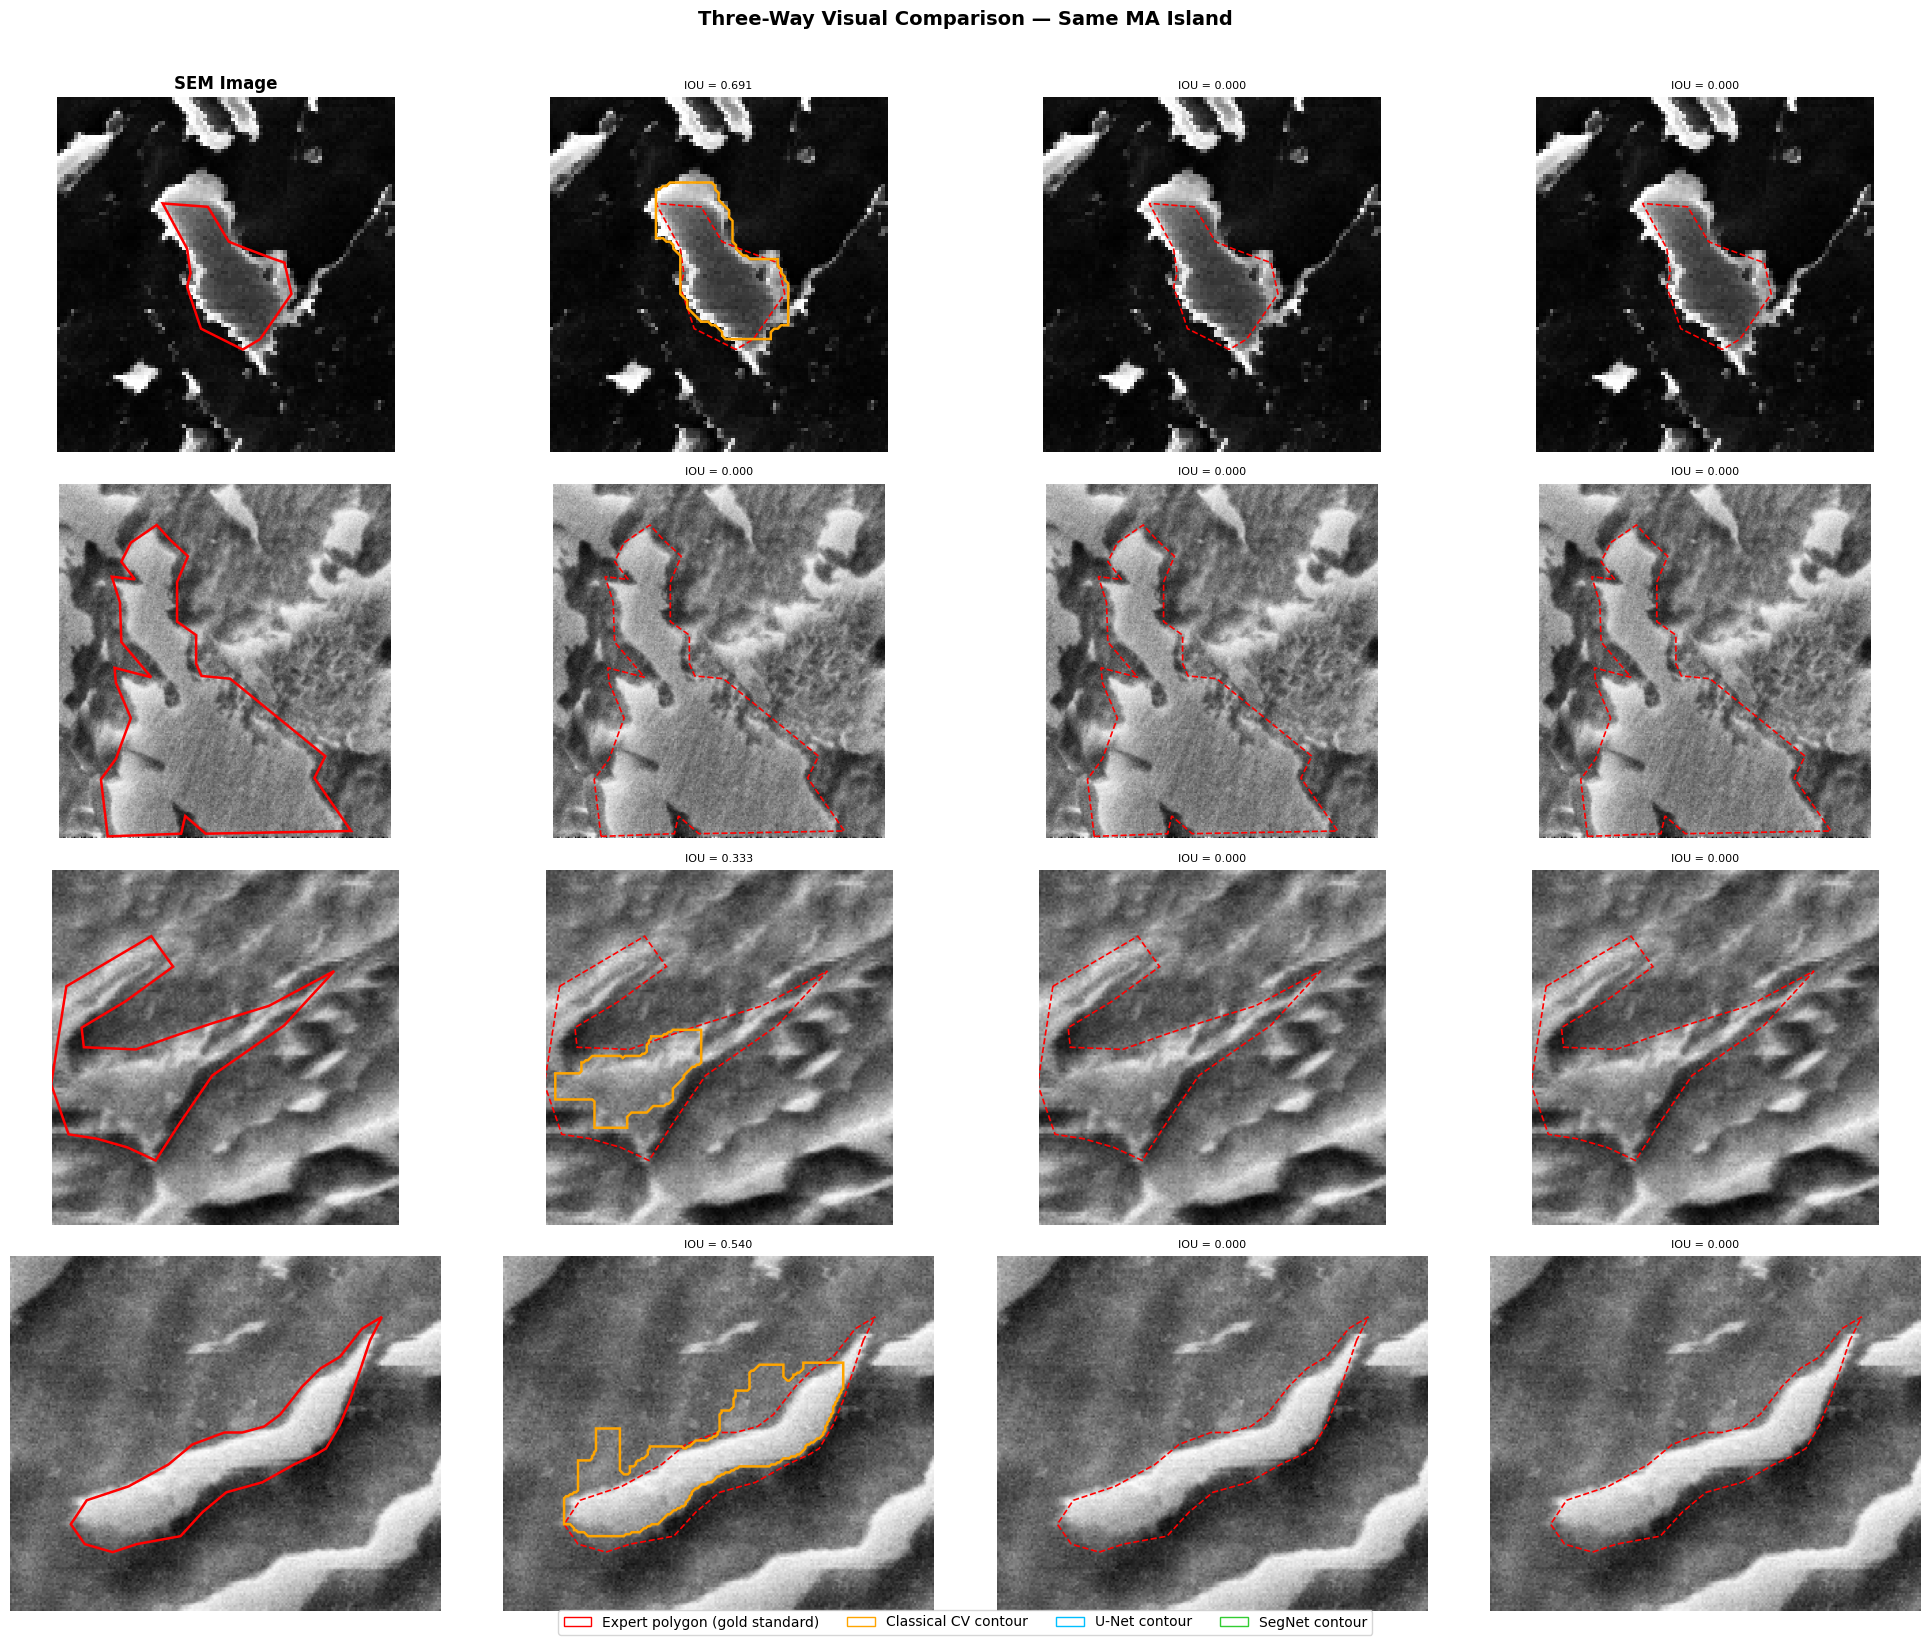

In [16]:
# Show failure cases — islands where all models struggled
failure_lookup = iou_lookup[
    ((iou_lookup['IOU_UNet'] + iou_lookup['IOU_SegNet']) / 2) < 0.1
]
print(f'Failure cases (avg DL IOU < 0.10): {len(failure_lookup)}')

visualize_three_way(
    failure_lookup,
    dfClassicalContours, dfUNetContours, dfSegNetContours,
    path_folder_images_png,
    n_samples=4, min_avg_iou=0.0, random_state=42
)

---
## 11. Architecture & Speed Comparison

Re-instantiates both model architectures from scratch (no training needed)
to count parameters and benchmark inference speed per patch.

In [17]:
# ── Re-define architectures (identical to respective training notebooks) ───────

# --- U-Net ---
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(True),
        )
    def forward(self, x): return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, features=(64, 128, 256, 512)):
        super().__init__()
        self.downs = nn.ModuleList()
        self.ups   = nn.ModuleList()
        self.pool  = nn.MaxPool2d(2, 2)
        ch = in_ch
        for f in features:
            self.downs.append(DoubleConv(ch, f)); ch = f
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)
        for f in reversed(features):
            self.ups.append(nn.ConvTranspose2d(f * 2, f, 2, 2))
            self.ups.append(DoubleConv(f * 2, f))
        self.final = nn.Conv2d(features[0], out_ch, 1)
    def forward(self, x):
        skips = []
        for d in self.downs:
            x = d(x); skips.append(x); x = self.pool(x)
        x = self.bottleneck(x); skips = skips[::-1]
        for i in range(0, len(self.ups), 2):
            x = self.ups[i](x); s = skips[i // 2]
            if x.shape != s.shape: x = TF.resize(x, s.shape[2:])
            x = torch.cat([s, x], 1); x = self.ups[i + 1](x)
        return torch.sigmoid(self.final(x))

# --- SegNet ---
class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(True),
        )
    def forward(self, x): return self.block(x)

class SegNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1):
        super().__init__()
        self.pool   = nn.MaxPool2d(2, 2, return_indices=True)
        self.unpool = nn.MaxUnpool2d(2, 2)
        self.enc1 = nn.Sequential(ConvBNReLU(in_ch,  64), ConvBNReLU(64,  64))
        self.enc2 = nn.Sequential(ConvBNReLU(64,  128),  ConvBNReLU(128, 128))
        self.enc3 = nn.Sequential(ConvBNReLU(128, 256),  ConvBNReLU(256, 256))
        self.enc4 = nn.Sequential(ConvBNReLU(256, 512),  ConvBNReLU(512, 512))
        self.enc5 = nn.Sequential(ConvBNReLU(512, 512),  ConvBNReLU(512, 512))
        self.dec5 = nn.Sequential(ConvBNReLU(512, 512),  ConvBNReLU(512, 512))
        self.dec4 = nn.Sequential(ConvBNReLU(512, 512),  ConvBNReLU(512, 256))
        self.dec3 = nn.Sequential(ConvBNReLU(256, 256),  ConvBNReLU(256, 128))
        self.dec2 = nn.Sequential(ConvBNReLU(128, 128),  ConvBNReLU(128,  64))
        self.dec1 = nn.Sequential(ConvBNReLU(64,   64),  ConvBNReLU(64,   64))
        self.final = nn.Conv2d(64, out_ch, 1)
    def forward(self, x):
        x1 = self.enc1(x);  x, i1 = self.pool(x1)
        x2 = self.enc2(x);  x, i2 = self.pool(x2)
        x3 = self.enc3(x);  x, i3 = self.pool(x3)
        x4 = self.enc4(x);  x, i4 = self.pool(x4)
        x5 = self.enc5(x);  x, i5 = self.pool(x5)
        x = self.unpool(x, i5, output_size=x5.size()); x = self.dec5(x)
        x = self.unpool(x, i4, output_size=x4.size()); x = self.dec4(x)
        x = self.unpool(x, i3, output_size=x3.size()); x = self.dec3(x)
        x = self.unpool(x, i2, output_size=x2.size()); x = self.dec2(x)
        x = self.unpool(x, i1, output_size=x1.size()); x = self.dec1(x)
        return torch.sigmoid(self.final(x))


# Instantiate (random weights — only needed for parameter count & speed)
unet_ref   = UNet().to(DEVICE)
segnet_ref = SegNet().to(DEVICE)

unet_params   = sum(p.numel() for p in unet_ref.parameters())
segnet_params = sum(p.numel() for p in segnet_ref.parameters())
print(f'U-Net  parameters : {unet_params:,}')
print(f'SegNet parameters : {segnet_params:,}')
print(f'SegNet / U-Net param ratio: {segnet_params/unet_params:.2f}x')

U-Net  parameters : 31,036,481
SegNet parameters : 18,849,025
SegNet / U-Net param ratio: 0.61x


In [18]:
# ── Inference speed benchmark ─────────────────────────────────────────────────
N_RUNS = 50
dummy  = torch.zeros(1, 1, PATCH_SIZE, PATCH_SIZE).to(DEVICE)

def benchmark(model, name, n=N_RUNS):
    model.eval()
    with torch.no_grad():
        for _ in range(5):              # warm-up
            model(dummy)
        t0 = time.perf_counter()
        for _ in range(n):
            model(dummy)
        elapsed = (time.perf_counter() - t0) / n * 1000
    print(f'{name:8s}: {elapsed:.2f} ms / {PATCH_SIZE}×{PATCH_SIZE} patch')
    return elapsed

t_unet   = benchmark(unet_ref,   'U-Net')
t_segnet = benchmark(segnet_ref, 'SegNet')

faster, slower, ratio = (
    ('SegNet', 'U-Net',  t_unet   / t_segnet) if t_segnet < t_unet else
    ('U-Net',  'SegNet', t_segnet / t_unet)
)
print(f'\n{faster} is {ratio:.2f}x faster than {slower} per patch.')

U-Net   : 780.95 ms / 256×256 patch
SegNet  : 538.94 ms / 256×256 patch

SegNet is 1.45x faster than U-Net per patch.


---
## 12. Final Summary Table

In [19]:
final_summary = pd.DataFrame({
    'Metric' : [
        'Mean IOU', 'Median IOU', 'Std IOU',
        'Detection rate (%)', 'IOU > 0.5 (%)', 'IOU > 0.75 (%)',
        'Parameters (M)', 'Inference speed (ms/patch)',
        'Skip connections', 'Upsampling method',
    ],
    'Classical CV' : [
        round(dfClassical['IOU'].mean(),   4),
        round(dfClassical['IOU'].median(), 4),
        round(dfClassical['IOU'].std(),    4),
        round((dfClassical['IOU'] >  0   ).sum() / len(dfClassical) * 100, 1),
        round((dfClassical['IOU'] >  0.50).sum() / len(dfClassical) * 100, 1),
        round((dfClassical['IOU'] >  0.75).sum() / len(dfClassical) * 100, 1),
        'N/A', 'N/A', 'N/A', 'Threshold + Morphology',
    ],
    'U-Net' : [
        round(dfUNet['IOU'].mean(),   4),
        round(dfUNet['IOU'].median(), 4),
        round(dfUNet['IOU'].std(),    4),
        round((dfUNet['IOU'] >  0   ).sum() / len(dfUNet) * 100, 1),
        round((dfUNet['IOU'] >  0.50).sum() / len(dfUNet) * 100, 1),
        round((dfUNet['IOU'] >  0.75).sum() / len(dfUNet) * 100, 1),
        round(unet_params / 1e6, 2), round(t_unet, 2),
        'Yes (full feature maps)', 'Transposed convolution',
    ],
    'SegNet' : [
        round(dfSegNet['IOU'].mean(),   4),
        round(dfSegNet['IOU'].median(), 4),
        round(dfSegNet['IOU'].std(),    4),
        round((dfSegNet['IOU'] >  0   ).sum() / len(dfSegNet) * 100, 1),
        round((dfSegNet['IOU'] >  0.50).sum() / len(dfSegNet) * 100, 1),
        round((dfSegNet['IOU'] >  0.75).sum() / len(dfSegNet) * 100, 1),
        round(segnet_params / 1e6, 2), round(t_segnet, 2),
        'No (indices only)', 'Max-unpool with saved indices',
    ],
}).set_index('Metric')

print('\n=== FINAL COMPARISON TABLE ===')
print(final_summary.to_string())
final_summary


=== FINAL COMPARISON TABLE ===
                                      Classical CV                    U-Net                         SegNet
Metric                                                                                                    
Mean IOU                                    0.3578                   0.4025                         0.4298
Median IOU                                  0.3863                   0.4478                         0.4813
Std IOU                                     0.2615                   0.3179                         0.3139
Detection rate (%)                            77.1                     70.4                           75.3
IOU > 0.5 (%)                                 36.3                     45.3                           48.3
IOU > 0.75 (%)                                 4.8                     17.8                           20.6
Parameters (M)                                 N/A                    31.04                          18.85
Infer

,Classical CV,U-Net,SegNet
Metric,,,
Mean IOU,0.3578,0.4025,0.4298
Median IOU,0.3863,0.4478,0.4813
Std IOU,0.2615,0.3179,0.3139
Detection rate (%),77.1,70.4,75.3
IOU > 0.5 (%),36.3,45.3,48.3
IOU > 0.75 (%),4.8,17.8,20.6
Parameters (M),N/A,31.04,18.85
Inference speed (ms/patch),N/A,780.95,538.94
Skip connections,N/A,Yes (full feature maps),No (indices only)


---
## 13. Interpretation & Recommendations

### Why U-Net typically outperforms SegNet on MA island boundaries

MA islands have **very fine, irregular boundaries** — exactly the scenario
where U-Net's full skip connections give it an advantage over SegNet's
index-only upsampling:

- **U-Net skip connections** transfer complete high-resolution feature maps
  from encoder to decoder at each depth level.  The decoder can recover fine
  spatial detail that was lost during max-pooling.

- **SegNet max-pool indices** only record *where* the max was in each 2×2
  window, not *what the neighbourhood looked like*.  Unpooling produces a
  sparse map filled purely through learned convolutions, without the rich
  feature context that U-Net skips provide.

For coarser segmentation tasks (e.g. road/lane detection, large organ
segmentation), SegNet is often competitive and uses less GPU memory.
For microscopy with small, abstract structures like MA islands, U-Net
is the more suitable architecture.

### Suggested next steps

1. **Attention U-Net** — adds channel/spatial attention gates on the skip
   connections, suppressing irrelevant background features and focusing on
   island boundaries.
2. **TransUNet / Swin-UNet** — replaces the CNN encoder with a Vision
   Transformer for global context modelling alongside local features.
3. **Mask R-CNN** — instance segmentation model that outputs a separate
   mask per detected island, removing the need for POI-guided component
   selection entirely.
4. **Ensemble** — average probability maps from U-Net and SegNet to exploit
   their complementary error patterns; particularly beneficial for islands
   where one model consistently fails.